In [2]:
print("Hello! CinePredict AI has started 🎬")

Hello! CinePredict AI has started 🎬


In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn plotly joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
df = pd.read_csv("../data/tmdb_5000_movies.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
df.shape

(4803, 20)

In [5]:
df.columns.tolist()

['budget',
 'genres',
 'homepage',
 'id',
 'keywords',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'vote_average',
 'vote_count']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [7]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [8]:
df.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
missing = df.isnull().sum()

missing[missing > 0]

homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

In [11]:
df['revenue'].describe()

count    4.803000e+03
mean     8.226064e+07
std      1.628571e+08
min      0.000000e+00
25%      0.000000e+00
50%      1.917000e+07
75%      9.291719e+07
max      2.787965e+09
Name: revenue, dtype: float64

In [12]:
(df['budget'] == 0).sum()

np.int64(1037)

In [13]:
(df['revenue'] == 0).sum()

np.int64(1427)

In [14]:
movie_df = df.copy()

In [15]:
movie_df = movie_df[
    (movie_df['budget'] > 0) &
    (movie_df['revenue'] > 0)
]

In [16]:
movie_df.shape

(3229, 20)

In [17]:
movie_df['roi'] = (
    (movie_df['revenue'] - movie_df['budget'])
    / movie_df['budget']
)

In [18]:
movie_df[['title', 'budget', 'revenue', 'roi']].head()

,title,budget,revenue,roi
0,Avatar,237000000,2787965087,10.763566
1,Pirates of the Caribbean: At World's End,300000000,961000000,2.203333
2,Spectre,245000000,880674609,2.594590
3,The Dark Knight Rises,250000000,1084939099,3.339756
4,John Carter,260000000,284139100,0.092843


In [19]:
movie_df['roi'].describe()

count    3.229000e+03
mean     2.953822e+03
std      1.506101e+05
min     -9.999995e-01
25%      2.246328e-02
50%      1.300366e+00
75%      3.420822e+00
max      8.499999e+06
Name: roi, dtype: float64

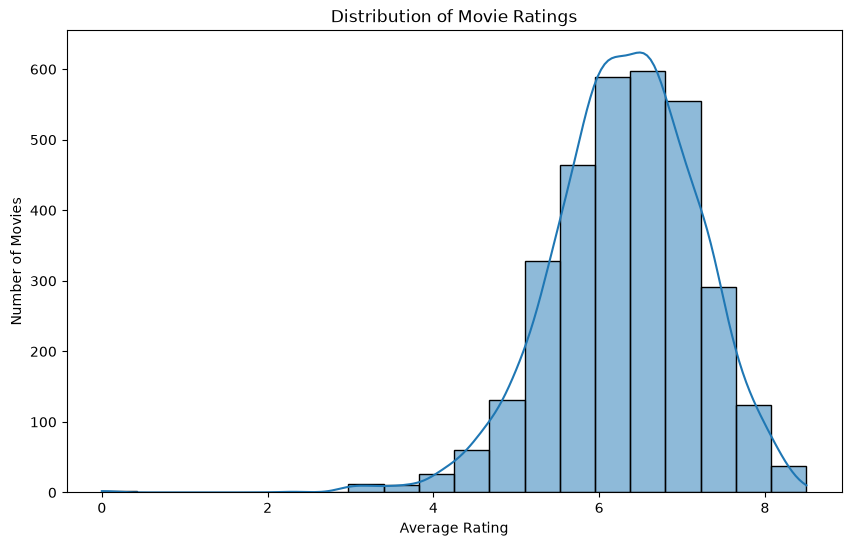

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movie_df['vote_average'],
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")

plt.show()

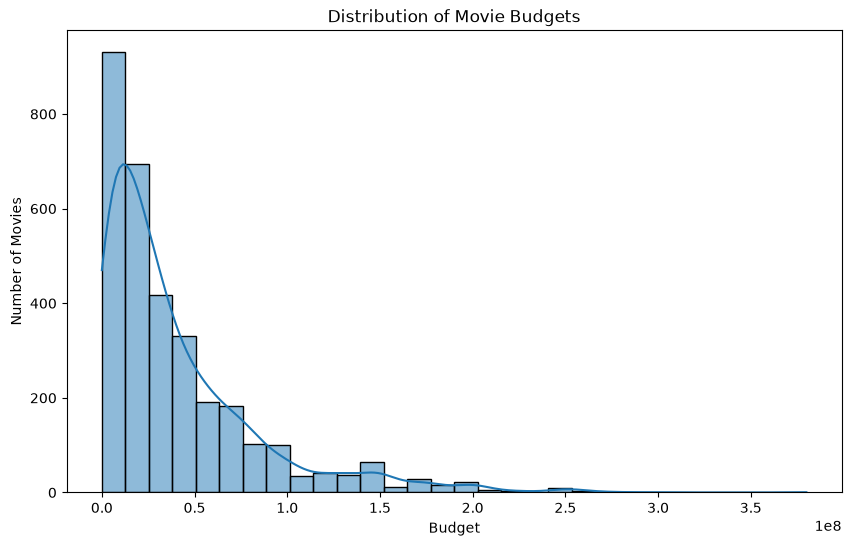

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movie_df['budget'],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget")
plt.ylabel("Number of Movies")

plt.show()

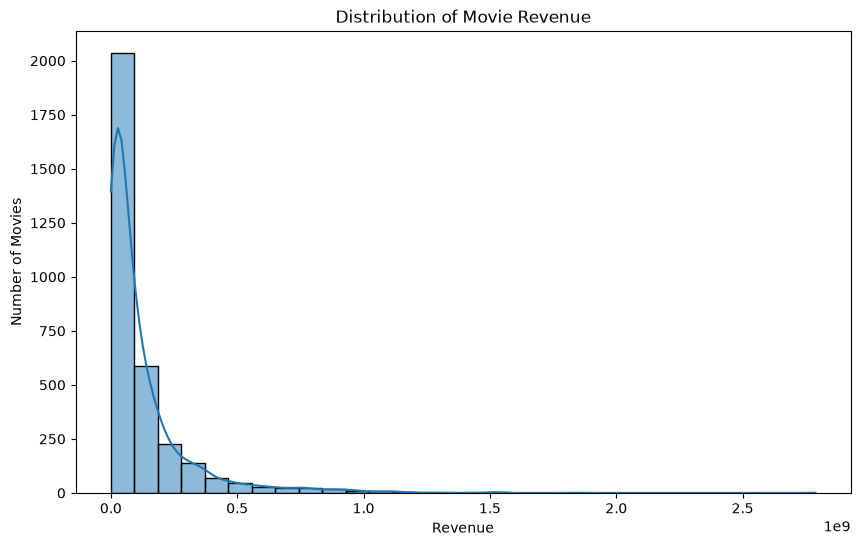

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movie_df['revenue'],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")

plt.show()

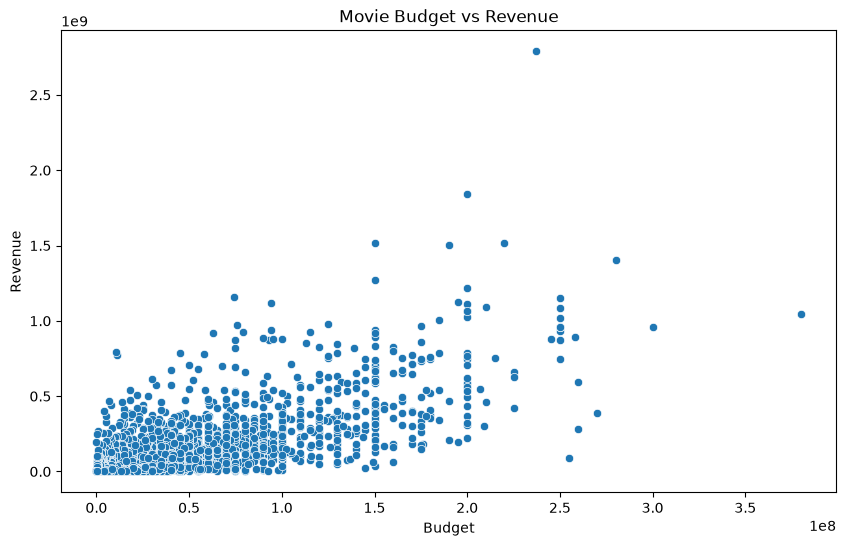

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movie_df,
    x='budget',
    y='revenue'
)

plt.title("Movie Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

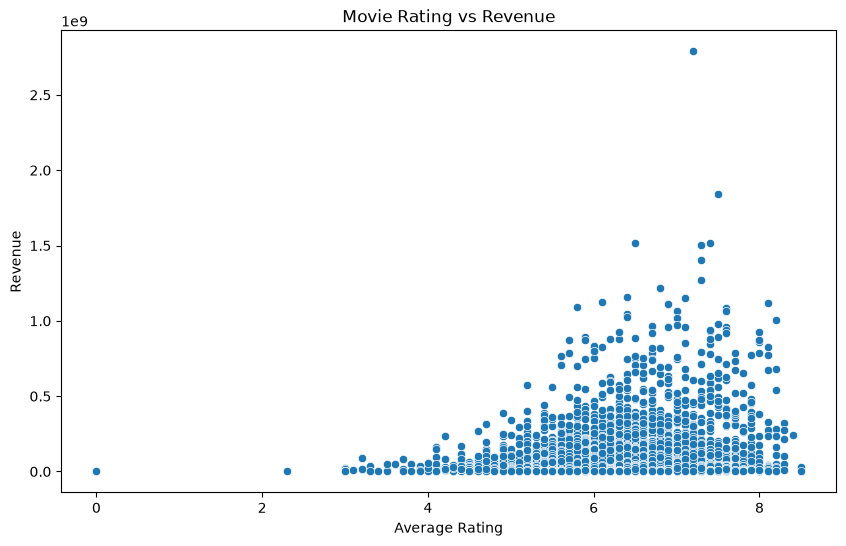

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movie_df,
    x='vote_average',
    y='revenue'
)

plt.title("Movie Rating vs Revenue")
plt.xlabel("Average Rating")
plt.ylabel("Revenue")

plt.show()

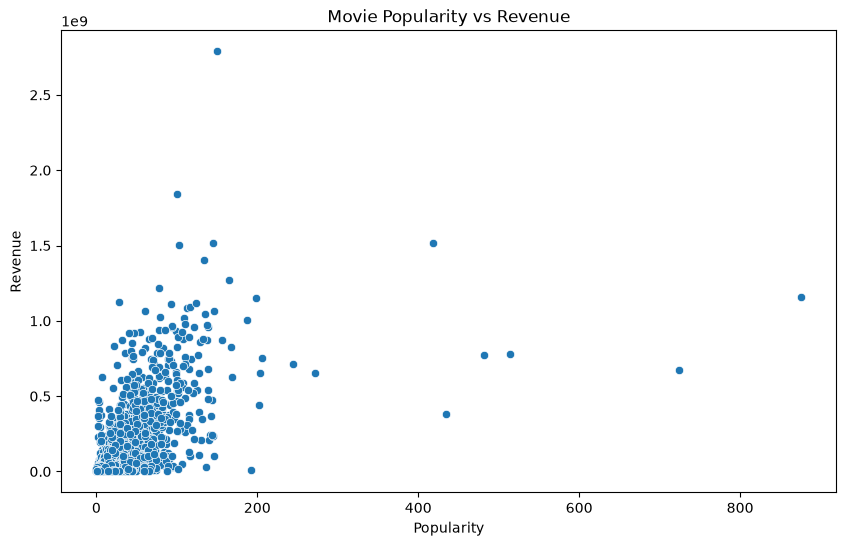

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movie_df,
    x='popularity',
    y='revenue'
)

plt.title("Movie Popularity vs Revenue")
plt.xlabel("Popularity")
plt.ylabel("Revenue")

plt.show()

In [26]:
numeric_columns = movie_df.select_dtypes(
    include=np.number
)

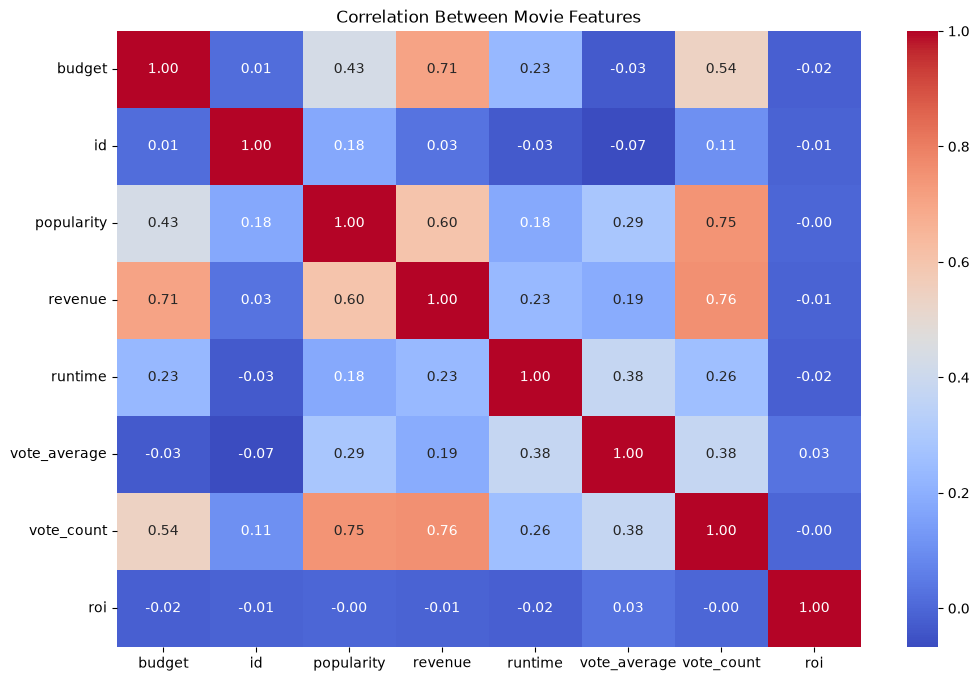

In [27]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Movie Features")

plt.show()

In [28]:
import ast

def extract_genres(text):
    try:
        genres = ast.literal_eval(text)
        return [genre['name'] for genre in genres]
    except:
        return []

movie_df['genre_list'] = movie_df['genres'].apply(extract_genres)

In [29]:
from collections import Counter

genre_counts = Counter(
    genre
    for genres in movie_df['genre_list']
    for genre in genres
)

genre_counts

Counter({'Drama': 1441,
         'Comedy': 1110,
         'Thriller': 935,
         'Action': 918,
         'Adventure': 661,
         'Romance': 574,
         'Crime': 521,
         'Science Fiction': 431,
         'Family': 365,
         'Fantasy': 342,
         'Horror': 332,
         'Mystery': 265,
         'Animation': 188,
         'History': 145,
         'War': 120,
         'Music': 111,
         'Western': 57,
         'Documentary': 38,
         'Foreign': 5})

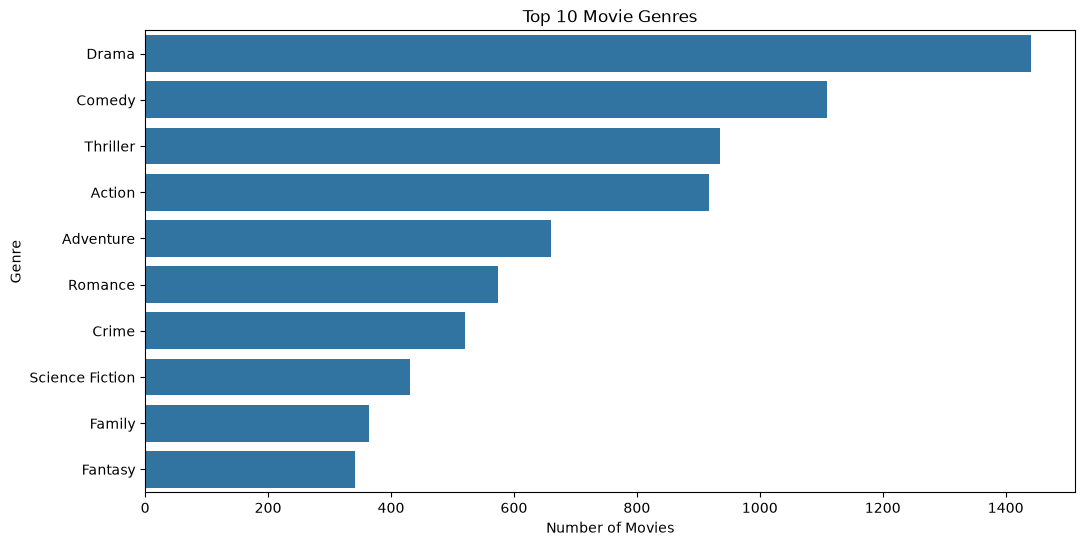

In [31]:
genre_df = pd.DataFrame(
    genre_counts.items(),
    columns=['Genre', 'Movies']
)

genre_df = genre_df.sort_values(
    'Movies',
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=genre_df.head(10),
    x='Movies',
    y='Genre'
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

In [32]:
movie_df['roi'].describe()

count    3.229000e+03
mean     2.953822e+03
std      1.506101e+05
min     -9.999995e-01
25%      2.246328e-02
50%      1.300366e+00
75%      3.420822e+00
max      8.499999e+06
Name: roi, dtype: float64

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
q25 = movie_df['roi'].quantile(0.25)
q75 = movie_df['roi'].quantile(0.75)

def classify_success(roi):
    if roi <= q25:
        return "Flop"
    elif roi >= q75:
        return "Hit"
    else:
        return "Average"

movie_df['success'] = movie_df['roi'].apply(classify_success)

print("25th percentile:", q25)
print("75th percentile:", q75)

25th percentile: 0.022463283333333334
75th percentile: 3.4208215571428573


In [36]:
movie_df['success'].value_counts()

success
Average    1613
Hit         808
Flop        808
Name: count, dtype: int64

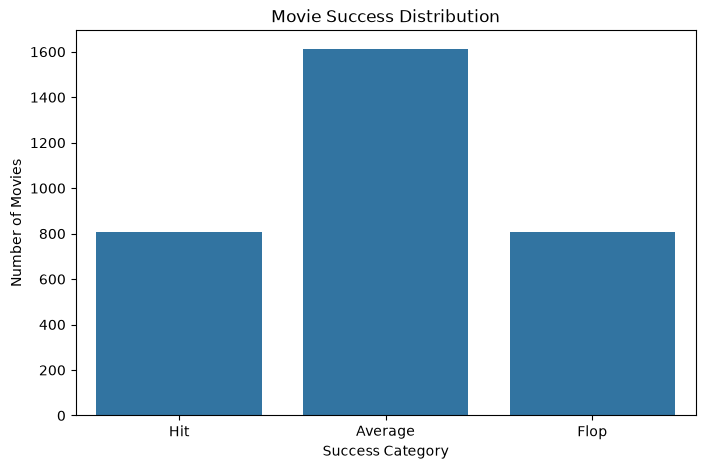

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=movie_df,
    x='success'
)

plt.title("Movie Success Distribution")
plt.xlabel("Success Category")
plt.ylabel("Number of Movies")

plt.show()

In [39]:
movie_df.groupby('success')['roi'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
success,,,,,
Average,1613,1.434036,1.300366,0.025607,3.418503e+00
Flop,808,-0.507504,-0.509407,-0.999999,2.246328e-02
Hit,808,11801.967224,6.524029,3.420822,8.499999e+06


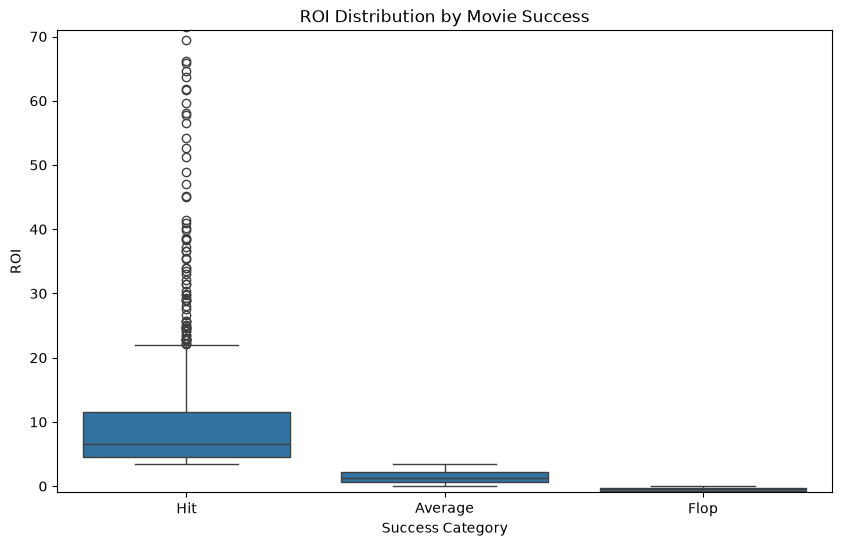

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movie_df,
    x='success',
    y='roi'
)

plt.title("ROI Distribution by Movie Success")
plt.xlabel("Success Category")
plt.ylabel("ROI")

plt.ylim(
    movie_df['roi'].quantile(0.01),
    movie_df['roi'].quantile(0.99)
)

plt.show()

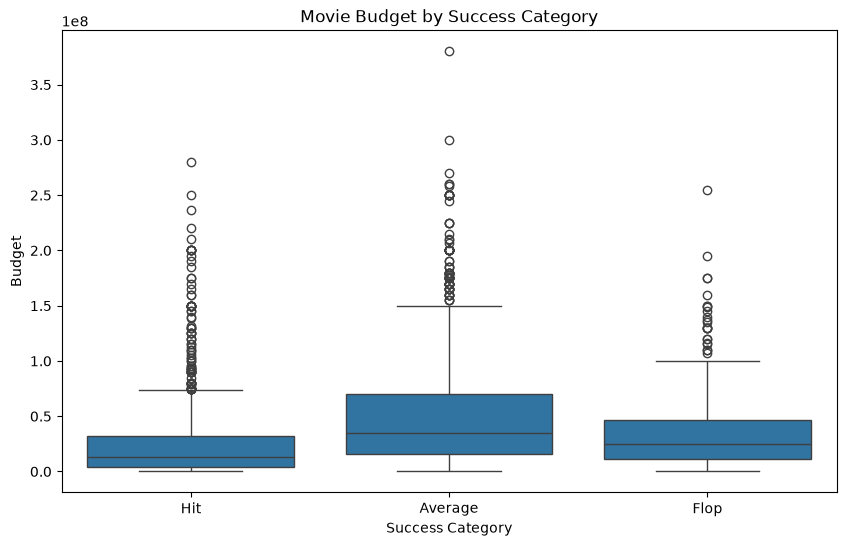

In [41]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movie_df,
    x='success',
    y='budget'
)

plt.title("Movie Budget by Success Category")
plt.xlabel("Success Category")
plt.ylabel("Budget")

plt.show()

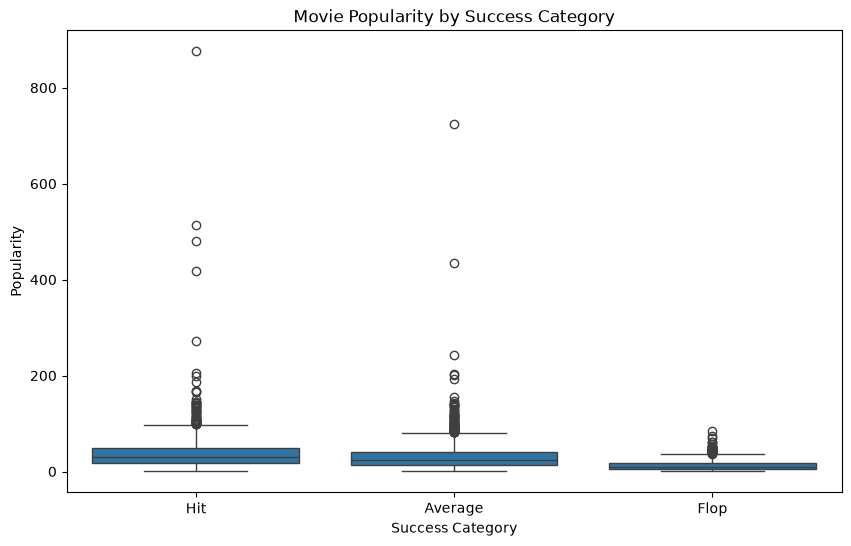

In [42]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movie_df,
    x='success',
    y='popularity'
)

plt.title("Movie Popularity by Success Category")
plt.xlabel("Success Category")
plt.ylabel("Popularity")

plt.show()

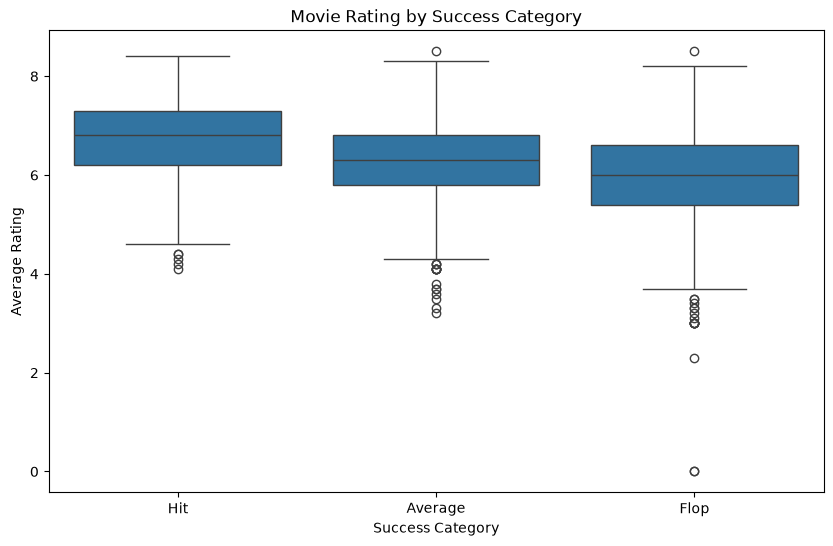

In [43]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movie_df,
    x='success',
    y='vote_average'
)

plt.title("Movie Rating by Success Category")
plt.xlabel("Success Category")
plt.ylabel("Average Rating")

plt.show()

In [44]:
movie_df['release_date'] = pd.to_datetime(
    movie_df['release_date'],
    errors='coerce'
)

movie_df['release_year'] = movie_df['release_date'].dt.year

In [45]:
movie_df[['title', 'release_date', 'release_year']].head()

,title,release_date,release_year
0,Avatar,2009-12-10,2009
1,Pirates of the Caribbean: At World's End,2007-05-19,2007
2,Spectre,2015-10-26,2015
3,The Dark Knight Rises,2012-07-16,2012
4,John Carter,2012-03-07,2012


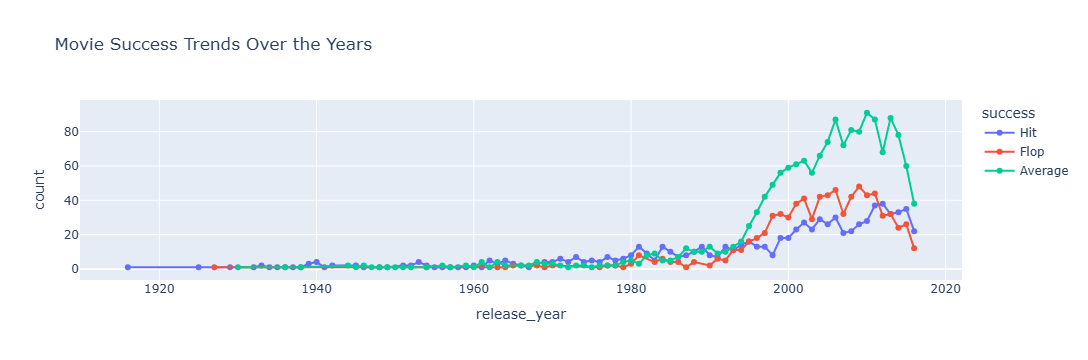

In [46]:
year_success = (
    movie_df.groupby(
        ['release_year', 'success']
    )
    .size()
    .reset_index(name='count')
)

fig = px.line(
    year_success,
    x='release_year',
    y='count',
    color='success',
    markers=True,
    title='Movie Success Trends Over the Years'
)

fig.show()

In [47]:
movie_df['success'].value_counts()

success
Average    1613
Hit         808
Flop        808
Name: count, dtype: int64

In [48]:
movie_df.groupby('success')['roi'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
success,,,,,
Average,1613,1.434036,1.300366,0.025607,3.418503e+00
Flop,808,-0.507504,-0.509407,-0.999999,2.246328e-02
Hit,808,11801.967224,6.524029,3.420822,8.499999e+06


In [49]:
features = [
    'budget',
    'runtime',
    'popularity',
    'vote_average',
    'vote_count',
    'release_year'
]

X = movie_df[features]
y = movie_df['success']

print("Features:")
print(features)

print("\nTarget:")
print("success")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['budget', 'runtime', 'popularity', 'vote_average', 'vote_count', 'release_year']

Target:
success

X shape: (3229, 6)
y shape: (3229,)


In [50]:
X.head()

,budget,runtime,popularity,vote_average,vote_count,release_year
0,237000000,162.0,150.437577,7.2,11800,2009
1,300000000,169.0,139.082615,6.9,4500,2007
2,245000000,148.0,107.376788,6.3,4466,2015
3,250000000,165.0,112.312950,7.6,9106,2012
4,260000000,132.0,43.926995,6.1,2124,2012


In [51]:
X.isnull().sum()

budget          0
runtime         0
popularity      0
vote_average    0
vote_count      0
release_year    0
dtype: int64

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2583, 6)
Testing data: (646, 6)


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("ML libraries loaded successfully!")

ML libraries loaded successfully!


In [54]:
tree_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [55]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print(
    f"Decision Tree Accuracy: {tree_accuracy:.2%}"
)

Decision Tree Accuracy: 60.53%


In [56]:
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LogisticRegression(
        max_iter=2000
    ))
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [57]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print(
    f"Logistic Regression Accuracy: {logistic_accuracy:.2%}"
)

Logistic Regression Accuracy: 58.67%


In [58]:
rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [59]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    f"Random Forest Accuracy: {rf_accuracy:.2%}"
)

Random Forest Accuracy: 61.46%


In [60]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ],
    
    'Precision': [
        precision_score(
            y_test,
            logistic_pred,
            average='weighted'
        ),
        precision_score(
            y_test,
            tree_pred,
            average='weighted'
        ),
        precision_score(
            y_test,
            rf_pred,
            average='weighted'
        )
    ],
    
    'Recall': [
        recall_score(
            y_test,
            logistic_pred,
            average='weighted'
        ),
        recall_score(
            y_test,
            tree_pred,
            average='weighted'
        ),
        recall_score(
            y_test,
            rf_pred,
            average='weighted'
        )
    ],
    
    'F1 Score': [
        f1_score(
            y_test,
            logistic_pred,
            average='weighted'
        ),
        f1_score(
            y_test,
            tree_pred,
            average='weighted'
        ),
        f1_score(
            y_test,
            rf_pred,
            average='weighted'
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.586687,0.604166,0.586687,0.577566
1,Decision Tree,0.605263,0.605111,0.605263,0.597865
2,Random Forest,0.614551,0.628136,0.614551,0.614803


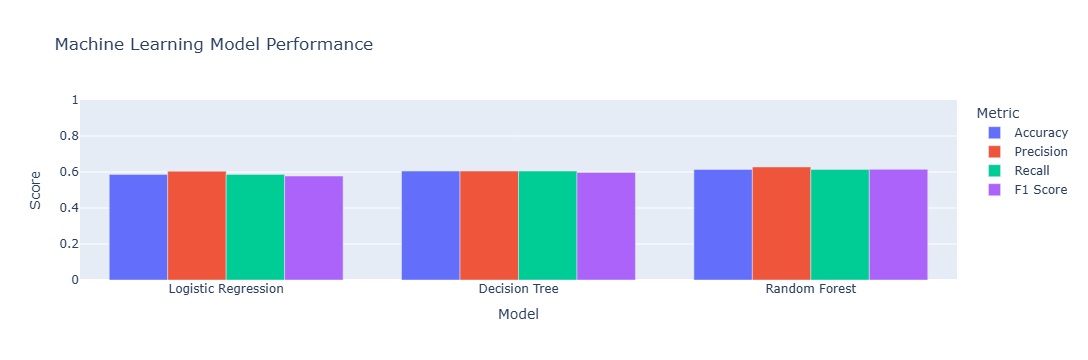

In [61]:
results_plot = results.melt(
    id_vars='Model',
    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    var_name='Metric',
    value_name='Score'
)

fig = px.bar(
    results_plot,
    x='Model',
    y='Score',
    color='Metric',
    barmode='group',
    title='Machine Learning Model Performance',
    range_y=[0, 1]
)

fig.show()

In [62]:
best_model_name = results.loc[
    results['F1 Score'].idxmax(),
    'Model'
]

print("🏆 Best Model:", best_model_name)

🏆 Best Model: Random Forest


In [63]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

     Average       0.68      0.55      0.61       323
        Flop       0.52      0.70      0.60       162
         Hit       0.63      0.66      0.64       161

    accuracy                           0.61       646
   macro avg       0.61      0.64      0.62       646
weighted avg       0.63      0.61      0.61       646



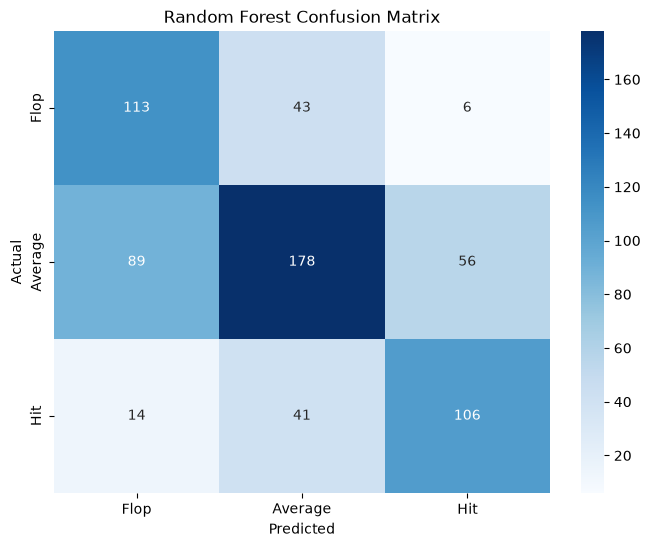

In [64]:
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=[
        'Flop',
        'Average',
        'Hit'
    ]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Flop',
        'Average',
        'Hit'
    ],
    yticklabels=[
        'Flop',
        'Average',
        'Hit'
    ]
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [65]:
rf = rf_model.named_steps['model']

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,vote_count,0.253833
0,budget,0.215222
2,popularity,0.185355
5,release_year,0.139728
3,vote_average,0.106097
1,runtime,0.099765


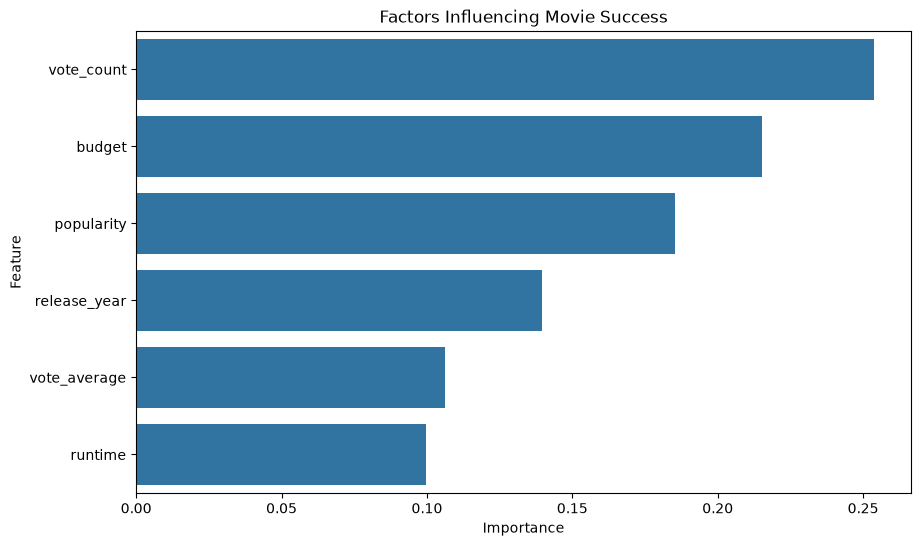

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Factors Influencing Movie Success'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [67]:
new_movie = pd.DataFrame({
    'budget': [50000000],
    'runtime': [120],
    'popularity': [80],
    'vote_average': [7.5],
    'vote_count': [5000],
    'release_year': [2026]
})

prediction = rf_model.predict(new_movie)

print("🎬 Predicted Movie Success:", prediction[0])

🎬 Predicted Movie Success: Hit


In [68]:
probabilities = rf_model.predict_proba(
    new_movie
)[0]

classes = rf_model.classes_

prediction_result = pd.DataFrame({
    'Category': classes,
    'Probability': probabilities
})

prediction_result

,Category,Probability
0,Average,0.309991
1,Flop,0.006092
2,Hit,0.683917


In [70]:
import joblib

joblib.dump(
    rf_model,
    '../models/cinepredict_model.pkl'
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [71]:
joblib.dump(
    features,
    '../models/features.pkl'
)

print("✅ Feature list saved successfully!")

✅ Feature list saved successfully!
